# 06 - Viabilidad de columnas para el dashboard VcM

**Fase:** diagnostico, no extraccion. El objetivo es verificar, columna por
columna y anio por anio, si es posible rescatar el conjunto de campos que la
contraparte de Vinculacion con el Medio (VcM) necesita para las metricas del
dashboard, *antes* de comprometer un alcance.

**Que hace este notebook**

1. Recorre todas las planillas fuente de `data/raw` (`.xlsm` por anio/instrumento
   y `.xlsx` expandidos de 2025) y lee la hoja principal de iniciativas de cada una.
2. Para cada una de las 8 columnas objetivo, busca la columna real por
   **palabras clave** (busqueda flexible, no coincidencia exacta), porque los
   nombres cambian entre las tres familias de formato (2022-2023, 2024, 2025).
3. Construye una **matriz de viabilidad** filas = columnas objetivo, columnas =
   anio, celda = % de cobertura, y la muestra como tabla y como heatmap.
4. Clasifica cada celda en **VIABLE / PARCIAL / NO DISPONIBLE**.
5. Verifica si los participantes vienen **desagregados** (estudiantes, academicos,
   titulados por separado) o solo como un **total agregado**.
6. Cierra con una recomendacion de alcance explicita y honesta.

**Alcance de seguridad:** es diagnostico puro. No modifica `src/`, no toca los
consolidados de `data/clean/` ni escribe nada. Solo lee `data/raw` y usa pandas,
matplotlib y seaborn.

Las 8 columnas objetivo:

1. Iniciativas (la unidad base, una por fila)
2. Estudiantes participantes
3. Academicos / docentes participantes
4. Titulados participantes
5. Emprendedores / empleadores participantes
6. Organizaciones de la sociedad civil participantes
7. Competencias (sello y/o genericas)
8. Catedras / asignaturas asociadas

In [1]:
import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Las planillas reales de SISAV traen validaciones de datos que openpyxl no
# soporta; los warnings no afectan la lectura de valores. Se silencian para
# mantener el output legible.
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="white")

RAW = Path("..") / "data" / "raw"
assert RAW.exists(), f"No existe {RAW.resolve()}"
print("Directorio de datos:", RAW.resolve())

Directorio de datos: C:\Users\ignac\vscode projects\visualizacion de datos\data\raw


## 1. Descubrimiento de archivos y deduplicacion

`data/raw` contiene algunas copias redundantes: archivos con el nombre mal
codificado (mojibake, con el caracter `Ã`) y copias marcadas con `(1)`. Son
versiones anteriores o parciales de los mismos exports de 2025 cuyo nombre
quedo bien escrito. Se excluyen para no contar dos veces las mismas iniciativas.
El criterio es transparente: se descarta todo archivo cuyo nombre contenga `Ã`
o un sufijo `(n)`, y se conserva el archivo de nombre limpio.

In [2]:
todos = sorted(p for p in RAW.iterdir() if p.suffix.lower() in (".xlsm", ".xlsx"))

duplicados, analizar = [], []
for p in todos:
    if ("\u00c3" in p.name) or re.search(r"\(\d+\)", p.stem):
        duplicados.append(p)
    else:
        analizar.append(p)

print("Excluidos como duplicados (mojibake / copia (n)):")
for p in duplicados:
    print("   -", p.name)

print(f"\nArchivos a analizar: {len(analizar)}")
for p in analizar:
    print("   +", p.name)

Excluidos como duplicados (mojibake / copia (n)):
   - EXTENSIÃN ACADÃMICA 2025 (1).xlsx
   - VINCULACIÃN CON EL ENTORNO DISCIPLINAR PROFESIONAL 2025 (1).xlsx
   - VINCULACIÃN CON TITULADOS 2025.xlsx

Archivos a analizar: 14
   + EXTENSIÓN ACADÉMICA 2025.xlsx
   + Plantilla EXT 2022.xlsm
   + Plantilla EXT 2023.xlsm
   + Plantilla EXT 2024.xlsm
   + Plantilla FCR 2022.xlsm
   + Plantilla FCR 2023.xlsm
   + Plantilla Iniciativas Centralizadas 2025.xlsm
   + Plantilla Iniciativas Centralizadas.xlsm
   + Plantilla UTG2024.xlsm
   + Plantilla VEDP 2022.xlsm
   + Plantilla VEDP 2023.xlsm
   + Plantilla VEDP 2024.xlsm
   + VINCULACIÓN CON EL ENTORNO DISCIPLINAR PROFESIONAL 2025.xlsx
   + VINCULACIÓN CON TITULADOS 2025.xlsx


## 2. Especificacion de las 8 columnas objetivo

Cada objetivo se define con palabras clave sobre el nombre **normalizado** de la
columna (minusculas, sin acentos, espacios colapsados). `any` = incluir la
columna si su nombre contiene alguno de esos terminos; `not` = descartarla si
contiene alguno (para evitar falsos positivos).

Detalles que motivan los filtros negativos:

- **Estudiantes participantes** excluye `catedra` y `asignatura`: la columna
  `N de estudiantes en catedra asociada` cuenta alumnos de la asignatura ligada,
  no participantes de la iniciativa.
- **Organizaciones** excluye `sello` (evita `Sello Institucional`), `competencia`
  y `persona` (evita `N de personas relacionadas a instituciones externas`, que
  cuenta personas, no organizaciones).
- **Catedras / asignaturas** excluye `estudiante` y `semestre`: interesa el
  nombre/codigo de la catedra, no el conteo de alumnos ni el semestre.

In [3]:
def norm(s):
    """Normaliza un nombre de columna: sin acentos, minuscula, espacios colapsados."""
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"\s+", " ", s.lower()).strip()


TARGETS = {
    "Iniciativas (unidad base)": {
        "any": ["nombre de la iniciativa", "nombre de iniciativa"],
        "not": [],
        "fallback_any": ["nombre"],
    },
    "Estudiantes participantes": {
        "any": ["estudiante"],
        "not": ["catedra", "asignatura"],
    },
    "Academicos / docentes participantes": {
        "any": ["docente", "academico"],
        "not": [],
    },
    "Titulados participantes": {
        "any": ["titulado"],
        "not": [],
    },
    "Emprendedores / empleadores participantes": {
        "any": ["emprendedor", "empleador"],
        "not": [],
    },
    "Organizaciones sociedad civil participantes": {
        "any": ["institucion", "sociedad civil", "organizacion"],
        "not": ["sello", "competencia", "estudiante", "persona"],
    },
    "Competencias (sello y/o genericas)": {
        "any": ["competencia", "sello institucional"],
        "not": [],
    },
    "Catedras / asignaturas asociadas": {
        "any": ["asignatura", "catedra"],
        "not": ["estudiante", "semestre"],
    },
}


def match_columns(cols, spec):
    """Devuelve las columnas reales que corresponden a un objetivo."""
    hits = []
    for c in cols:
        nc = norm(c)
        if any(k in nc for k in spec["any"]) and not any(k in nc for k in spec.get("not", [])):
            hits.append(c)
    if not hits and spec.get("fallback_any"):
        hits = [c for c in cols if any(k in norm(c) for k in spec["fallback_any"])]
    return hits


list(TARGETS)

['Iniciativas (unidad base)',
 'Estudiantes participantes',
 'Academicos / docentes participantes',
 'Titulados participantes',
 'Emprendedores / empleadores participantes',
 'Organizaciones sociedad civil participantes',
 'Competencias (sello y/o genericas)',
 'Catedras / asignaturas asociadas']

## 3. Lectura de hojas principales y mapeo de columnas

La hoja de iniciativas se llama distinto segun la familia de formato:

- 2022-2023 (`.xlsm`): hoja `PLANILLA`
- 2024 y centralizadas 2025 (`.xlsm`): hoja `Planilla`
- 2025 expandido (`.xlsx`): hoja que empieza con `Iniciativas` (`Iniciativas EA`,
  `Iniciativas VEDP`, `Iniciativas VCT`)

El **universo de filas** de cada archivo son las iniciativas reales: filas con
un identificador poblado (`Codigo` o nombre de iniciativa). Asi se excluyen las
filas de plantilla vacias que arrastrarian la cobertura hacia abajo de forma
artificial. El anio se toma del nombre del archivo y, si falta, del modo de una
columna de fecha.

In [4]:
def pick_main_sheet(sheets):
    for s in sheets:
        if s.lower().startswith("iniciativas"):
            return s
    for cand in ("PLANILLA", "Planilla"):
        if cand in sheets:
            return cand
    return sheets[0]


def is_populated(series):
    s = series.astype("string").str.strip()
    return s.notna() & (s != "") & (s.str.lower() != "nan")


def iniciativa_mask(df):
    """Fila = iniciativa real si tiene Codigo o Nombre de iniciativa poblado."""
    m = np.zeros(len(df), dtype=bool)
    for c in df.columns:
        nc = norm(c)
        if ("codigo" in nc) or ("nombre de la iniciativa" in nc) or \
           ("nombre de iniciativa" in nc) or (nc == "nombre"):
            m = m | is_populated(df[c]).to_numpy()
    return m


def infer_year(path, df):
    m = re.search(r"(20\d{2})", path.stem)
    if m:
        return int(m.group(1))
    for c in df.columns:
        nc = norm(c)
        if "fecha" in nc and any(k in nc for k in ("termin", "inicio", "finaliza")):
            years = pd.to_datetime(df[c], errors="coerce").dt.year.dropna()
            if len(years):
                return int(years.mode().iloc[0])
    return None


# Lee cada archivo una sola vez y guarda (anio, hoja, df de iniciativas reales).
datos = {}
for p in analizar:
    xls = pd.ExcelFile(p)
    hoja = pick_main_sheet(xls.sheet_names)
    df = pd.read_excel(p, sheet_name=hoja).dropna(how="all")
    df = df[iniciativa_mask(df)].reset_index(drop=True)
    anio = infer_year(p, df)
    datos[p.name] = {"anio": anio, "hoja": hoja, "df": df}
    print(f"{anio}  {p.name:65s} hoja={hoja:16s} iniciativas={len(df)}")

2025  EXTENSIÓN ACADÉMICA 2025.xlsx                                     hoja=Iniciativas EA   iniciativas=124
2022  Plantilla EXT 2022.xlsm                                           hoja=PLANILLA         iniciativas=71
2023  Plantilla EXT 2023.xlsm                                           hoja=PLANILLA         iniciativas=71
2024  Plantilla EXT 2024.xlsm                                           hoja=Planilla         iniciativas=56
2022  Plantilla FCR 2022.xlsm                                           hoja=PLANILLA         iniciativas=15
2023  Plantilla FCR 2023.xlsm                                           hoja=PLANILLA         iniciativas=18
2025  Plantilla Iniciativas Centralizadas 2025.xlsm                     hoja=Planilla         iniciativas=45
None  Plantilla Iniciativas Centralizadas.xlsm                          hoja=Planilla         iniciativas=61
2024  Plantilla UTG2024.xlsm                                            hoja=Planilla         iniciativas=17
2022  Plantilla VE

### 3.1 Que columna real quedo mapeada a cada objetivo

Antes de agregar por anio conviene ver, archivo por archivo, que columnas reales
capturo la busqueda por palabras clave. Esta es la evidencia de que el mapeo es
correcto (y de donde estan los huecos).

In [5]:
filas_mapeo = []
for nombre, info in datos.items():
    cols = info["df"].columns
    for tgt, spec in TARGETS.items():
        matched = match_columns(cols, spec)
        filas_mapeo.append({
            "anio": info["anio"],
            "archivo": nombre,
            "objetivo": tgt,
            "columnas_reales": " | ".join(map(str, matched)) if matched else "(no existe)",
        })

mapeo = pd.DataFrame(filas_mapeo)

# Vocabulario real encontrado por objetivo (columnas distintas en todo el corpus)
print("Nombres reales encontrados por objetivo:\n")
for tgt in TARGETS:
    reales = sorted({c for c in mapeo.loc[mapeo["objetivo"] == tgt, "columnas_reales"]
                     if c != "(no existe)"})
    print(f"# {tgt}")
    for r in reales:
        print("   ", r)
    if not reales:
        print("    (ninguna en ningun archivo)")
    print()

Nombres reales encontrados por objetivo:

# Iniciativas (unidad base)
    Nombre
    Nombre de iniciativa
    Nombre de la iniciativa
    Nombre | Nombre de Act Planificada | Nombre Actividad Eje

# Estudiantes participantes
    N Estudiantes
    N de estudiantes (M) | N de estudiantes (F) | N de estudiantes (Otro)
    N estudiantes

# Academicos / docentes participantes
    N Docentes
    N de académicos (M) | N de académicos (F) | N de académicos (Otro)

# Titulados participantes
    N Titulados
    N de titulados (M) | N de titulados (F) | N de titulados (Otro)

# Emprendedores / empleadores participantes
    (ninguna en ningun archivo)

# Organizaciones sociedad civil participantes
    N  Instituciones del medio externo participantes
    N de instituciones externas

# Competencias (sello y/o genericas)
    Competencia Sello | Competencia genérica
    Competencia sello | Competencias génericas
    Sello Institucional

# Catedras / asignaturas asociadas
    Nombre de asignatura asoci

## 4. Matriz de viabilidad (cobertura %)

Para cada archivo y objetivo, una fila esta *poblada* si al menos una de las
columnas mapeadas tiene valor (los conteos por sexo de 2025, por ejemplo, se
combinan: basta que M, F u Otro tenga dato). La cobertura por anio es
`filas pobladas / total de iniciativas del anio * 100`, sumando todos los
instrumentos de ese anio. Una celda es `NaN` (`n/d`) cuando la columna **no
existe** en ningun archivo de ese anio.

In [6]:
registros = []
for nombre, info in datos.items():
    df, anio, total = info["df"], info["anio"], len(info["df"])
    for tgt, spec in TARGETS.items():
        cols = match_columns(df.columns, spec)
        if cols:
            pobl = np.zeros(total, dtype=bool)
            for c in cols:
                pobl = pobl | is_populated(df[c]).to_numpy()
            poblada = int(pobl.sum())
        else:
            poblada = 0
        registros.append({"anio": anio, "archivo": nombre, "objetivo": tgt,
                          "existe": bool(cols), "poblada": poblada, "total": total})

reg = pd.DataFrame(registros)
anios = sorted(int(a) for a in reg["anio"].dropna().unique())

cobertura = pd.DataFrame(index=list(TARGETS), columns=anios, dtype=float)
presencia = pd.DataFrame(index=list(TARGETS), columns=anios, dtype=object)
for tgt in TARGETS:
    for a in anios:
        sub = reg[(reg["anio"] == a) & (reg["objetivo"] == tgt)]
        n_existe = int(sub["existe"].sum())
        tot = int(sub["total"].sum())
        cobertura.loc[tgt, a] = round(100 * sub["poblada"].sum() / tot, 1) if (n_existe and tot) else np.nan
        presencia.loc[tgt, a] = f"{n_existe}/{len(sub)}"

print("=== COBERTURA (% de iniciativas del anio con la columna poblada) ===\n")
print(cobertura.to_string(na_rep="n/d"))
print("\n=== PRESENCIA (en cuantos archivos del anio existe la columna) ===\n")
print(presencia.to_string())

=== COBERTURA (% de iniciativas del anio con la columna poblada) ===

                                              2022   2023   2024   2025
Iniciativas (unidad base)                    100.0  100.0  100.0  100.0
Estudiantes participantes                      n/d    n/d   98.9   99.1
Academicos / docentes participantes            n/d    n/d   98.3   99.4
Titulados participantes                        n/d    n/d   97.2   99.1
Emprendedores / empleadores participantes      n/d    n/d    n/d    n/d
Organizaciones sociedad civil participantes    n/d    n/d   95.5   80.9
Competencias (sello y/o genericas)            93.2   98.1   98.9  100.0
Catedras / asignaturas asociadas               n/d    n/d   56.8   58.6

=== PRESENCIA (en cuantos archivos del anio existe la columna) ===

                                            2022 2023 2024 2025
Iniciativas (unidad base)                    3/3  3/3  3/3  4/4
Estudiantes participantes                    0/3  0/3  3/3  4/4
Academicos / docentes

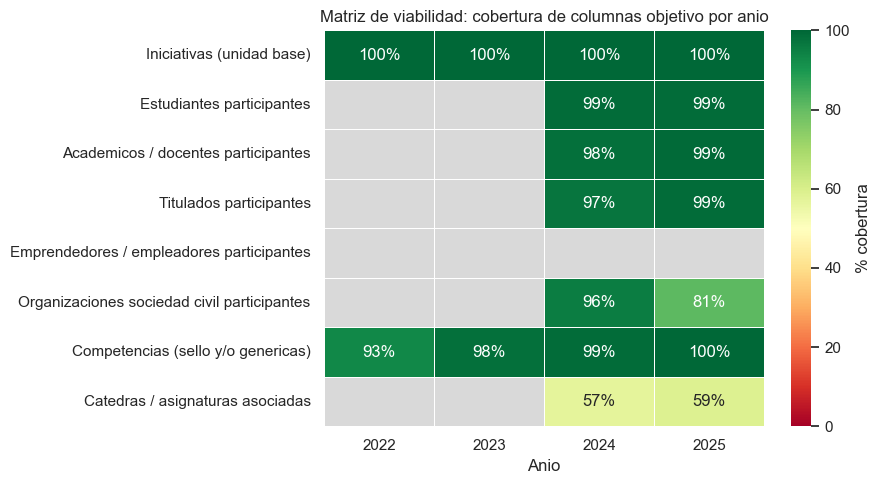

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
annot = cobertura.copy().astype(object)
for i in cobertura.index:
    for c in cobertura.columns:
        v = cobertura.loc[i, c]
        annot.loc[i, c] = "n/d" if pd.isna(v) else f"{v:.0f}%"

sns.heatmap(cobertura.astype(float), annot=annot.values, fmt="", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "% cobertura"},
            mask=cobertura.isna(), ax=ax)
ax.set_facecolor("#d9d9d9")  # celdas n/d en gris
ax.set_title("Matriz de viabilidad: cobertura de columnas objetivo por anio")
ax.set_xlabel("Anio")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Clasificacion VIABLE / PARCIAL / NO DISPONIBLE

- **VIABLE**: la columna existe y esta bien poblada (cobertura > 70%).
- **PARCIAL**: existe pero con huecos (0 < cobertura <= 70%), tipicamente porque
  solo algunos instrumentos del anio la traen.
- **NO DISPONIBLE**: la columna no existe en ningun archivo del anio, o existe
  pero esta practicamente vacia (cobertura = 0).

In [8]:
def clasificar(v):
    if pd.isna(v):
        return "NO DISPONIBLE"
    if v > 70:
        return "VIABLE"
    if v > 0:
        return "PARCIAL"
    return "NO DISPONIBLE"

clasif = cobertura.map(clasificar)
print(clasif.to_string())

                                                      2022           2023           2024           2025
Iniciativas (unidad base)                           VIABLE         VIABLE         VIABLE         VIABLE
Estudiantes participantes                    NO DISPONIBLE  NO DISPONIBLE         VIABLE         VIABLE
Academicos / docentes participantes          NO DISPONIBLE  NO DISPONIBLE         VIABLE         VIABLE
Titulados participantes                      NO DISPONIBLE  NO DISPONIBLE         VIABLE         VIABLE
Emprendedores / empleadores participantes    NO DISPONIBLE  NO DISPONIBLE  NO DISPONIBLE  NO DISPONIBLE
Organizaciones sociedad civil participantes  NO DISPONIBLE  NO DISPONIBLE         VIABLE         VIABLE
Competencias (sello y/o genericas)                  VIABLE         VIABLE         VIABLE         VIABLE
Catedras / asignaturas asociadas             NO DISPONIBLE  NO DISPONIBLE        PARCIAL        PARCIAL


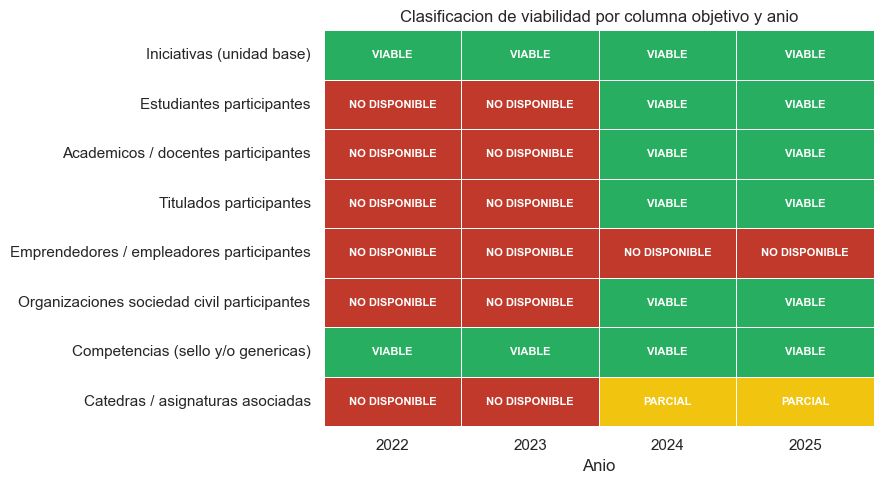

In [9]:
cat_num = {"NO DISPONIBLE": 0, "PARCIAL": 1, "VIABLE": 2}
num = clasif.replace(cat_num).astype(float)
cmap = ListedColormap(["#c0392b", "#f1c40f", "#27ae60"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(num, annot=clasif.values, fmt="", cmap=cmap, vmin=0, vmax=2,
            linewidths=0.5, linecolor="white", cbar=False, ax=ax,
            annot_kws={"color": "white", "weight": "bold", "fontsize": 8})
ax.set_title("Clasificacion de viabilidad por columna objetivo y anio")
ax.set_xlabel("Anio")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Desagregacion de participantes

Punto clave para decidir que metricas se pueden construir: los participantes
vienen **desagregados** por tipo (columnas separadas de estudiantes, academicos,
titulados, etc.) o solo como un **total agregado**. Sin desagregacion no se
pueden calcular indicadores por tipo de participante.

In [10]:
def tiene_total_agregado(df):
    for c in df.columns:
        nc = norm(c)
        if ("total asistentes" in nc) or (nc == "total") or ("total de participantes" in nc):
            return True
    return False

filas = []
for a in anios:
    est = cobertura.loc["Estudiantes participantes", a]
    aca = cobertura.loc["Academicos / docentes participantes", a]
    tit = cobertura.loc["Titulados participantes", a]
    desagregado = all(not pd.isna(x) for x in (est, aca, tit))
    total_agg = any(tiene_total_agregado(info["df"])
                    for info in datos.values() if info["anio"] == a)
    if desagregado:
        veredicto = "DESAGREGADO (estudiantes/academicos/titulados por separado)"
    elif total_agg:
        veredicto = "SOLO AGREGADO (unicamente un total, sin desglose por tipo)"
    else:
        veredicto = "SIN DATOS DE PARTICIPANTES"
    filas.append({"anio": a, "estudiantes_%": est, "academicos_%": aca,
                  "titulados_%": tit, "tiene_total_agregado": total_agg,
                  "veredicto": veredicto})

desag = pd.DataFrame(filas).set_index("anio")
print(desag.to_string(na_rep="n/d"))

      estudiantes_%  academicos_%  titulados_%  tiene_total_agregado                                                    veredicto
anio                                                                                                                             
2022            n/d           n/d          n/d                  True   SOLO AGREGADO (unicamente un total, sin desglose por tipo)
2023            n/d           n/d          n/d                  True   SOLO AGREGADO (unicamente un total, sin desglose por tipo)
2024           98.9          98.3         97.2                  True  DESAGREGADO (estudiantes/academicos/titulados por separado)
2025           99.1          99.4         99.1                  True  DESAGREGADO (estudiantes/academicos/titulados por separado)


## 7. Recomendacion de alcance

*(Sintesis de la evidencia anterior. Honesta sobre los huecos.)*

### Resumen por columna objetivo

| Columna objetivo | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|
| Iniciativas (unidad base) | VIABLE | VIABLE | VIABLE | VIABLE |
| Estudiantes participantes | NO DISP | NO DISP | VIABLE | VIABLE |
| Academicos / docentes | NO DISP | NO DISP | VIABLE | VIABLE |
| Titulados participantes | NO DISP | NO DISP | VIABLE | VIABLE |
| Emprendedores / empleadores | NO DISP | NO DISP | NO DISP | NO DISP |
| Organizaciones sociedad civil | NO DISP | NO DISP | VIABLE | VIABLE |
| Competencias (sello y/o genericas) | VIABLE (solo sello) | VIABLE (solo sello) | VIABLE | VIABLE |
| Catedras / asignaturas | NO DISP | NO DISP | PARCIAL | PARCIAL |

### Conclusiones

**Anios con cobertura suficiente para metricas confiables: 2024 y 2025.**

- Son los unicos anios donde los participantes vienen **desagregados** por tipo
  (estudiantes, academicos/docentes, titulados) con cobertura > 97%. Tambien
  traen el conteo de instituciones/organizaciones del medio externo y las
  competencias (sello y genericas). Sobre estos dos anios se pueden construir con
  confianza las metricas de participantes por tipo, de organizaciones y de
  competencias.
- 2025 es el formato mas rico: los conteos vienen incluso desagregados por sexo
  (M/F/Otro) y agregan academicos y funcionarios como categorias propias, ademas
  del nombre de la asignatura asociada.

**Anios que conviene excluir del alcance de participantes: 2022 y 2023.**

- Estos anios **no traen los participantes desagregados**. La unica cifra de
  personas es `Total Asistentes`, un agregado sin desglose por tipo. No es posible
  derivar de ahi estudiantes, academicos ni titulados por separado. Si se
  necesitan esas metricas, 2022 y 2023 deben quedar fuera (o limitarse a un
  indicador de asistentes totales, no comparable con el desglose de 2024-2025).
- De 2022-2023 solo se rescatan de forma fiable: la iniciativa como unidad y la
  competencia **sello** (no hay competencia generica en ese formato).

**Columnas problematicas en todos los anios:**

- **Emprendedores / empleadores participantes: NO DISPONIBLE en todos los anios.**
  Ningun formato tiene una columna de conteo de emprendedores o empleadores. En
  2025 lo mas cercano es `N de personas relacionadas a instituciones externas`,
  que cuenta personas de instituciones externas en general, no emprendedores ni
  empleadores especificamente. Si esta metrica es requisito, hay que levantarla
  con la contraparte porque el dato no existe en la fuente.
- **Catedras / asignaturas asociadas: PARCIAL en 2024 y 2025.** En 2024 solo el
  instrumento VEDP trae la catedra; EXT y UTG no. En 2025 la traen 3 de 4
  instrumentos. Sirve como atributo complementario, no como dimension con
  cobertura completa.

### Alcance recomendado

Construir el dashboard de participantes desagregados, organizaciones y
competencias **sobre 2024 y 2025**. Tratar 2022-2023 como serie historica
limitada (iniciativas + total de asistentes + competencia sello), claramente
etiquetada como no comparable con el desglose posterior. Dejar fuera del alcance
la metrica de emprendedores/empleadores hasta confirmar con VcM si el dato se
capturara en el instrumento; usar catedra/asignatura solo como atributo opcional.